# Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import OrdinalEncoder

%matplotlib inline
sns.set_style("darkgrid")

### 1. Load Processed Data

In [3]:
import sys

sys.path.insert(0, "..")
from src.data_preparation import load_and_prepare, get_feature_target_split

# Load raw for feature exploration (before encoding)
df_raw = pd.read_excel("../data/E Commerce Dataset.xlsx", sheet_name="E Comm")
df_raw.drop("CustomerID", axis=1, inplace=True)
df_raw["Tenure"] = df_raw["Tenure"].apply(lambda x: (x // 12) + 1)
df_raw.PreferredLoginDevice = df_raw.PreferredLoginDevice.replace(
    {"Mobile Phone": "Phone"}
)
df_raw.PreferredPaymentMode = df_raw.PreferredPaymentMode.replace(
    {"Cash on Delivery": "COD", "CC": "Credit Card"}
)
df_raw.PreferedOrderCat = df_raw.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})

churn = df_raw[df_raw.Churn == 1]
no_churn = df_raw[df_raw.Churn == 0]
print(df_raw.shape)

(5630, 19)


### 2. Pearson Correlations Between Numerical Features

In [ ]:
numerical_cols = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

df_clean = df_raw[numerical_cols].dropna()
print("Pearson Correlations (feature pairs):")
for i, col_i in enumerate(numerical_cols):
    for col_j in numerical_cols[i + 1 :]:
        r = pearsonr(df_clean[col_i], df_clean[col_j]).statistic
        if abs(r) > 0.1:
            print(f"  {col_i} x {col_j}: {r:.4f}")

Pearson Correlations (feature pairs):
  Tenure x CashbackAmount: 0.1786
  HourSpendOnApp x CouponUsed: 0.1602
  HourSpendOnApp x CashbackAmount: 0.1313
  CouponUsed x OrderCount: 0.7325
  CouponUsed x DaySinceLastOrder: 0.3195
  CouponUsed x CashbackAmount: 0.1674
  OrderCount x DaySinceLastOrder: 0.4573
  OrderCount x CashbackAmount: 0.2190
  DaySinceLastOrder x CashbackAmount: 0.2296


### 3. Candidate Interaction Terms — KDE Separation Test

Visual distribution separation between churners and non-churners. If the KDE curves overlap completely, the interaction adds no signal.

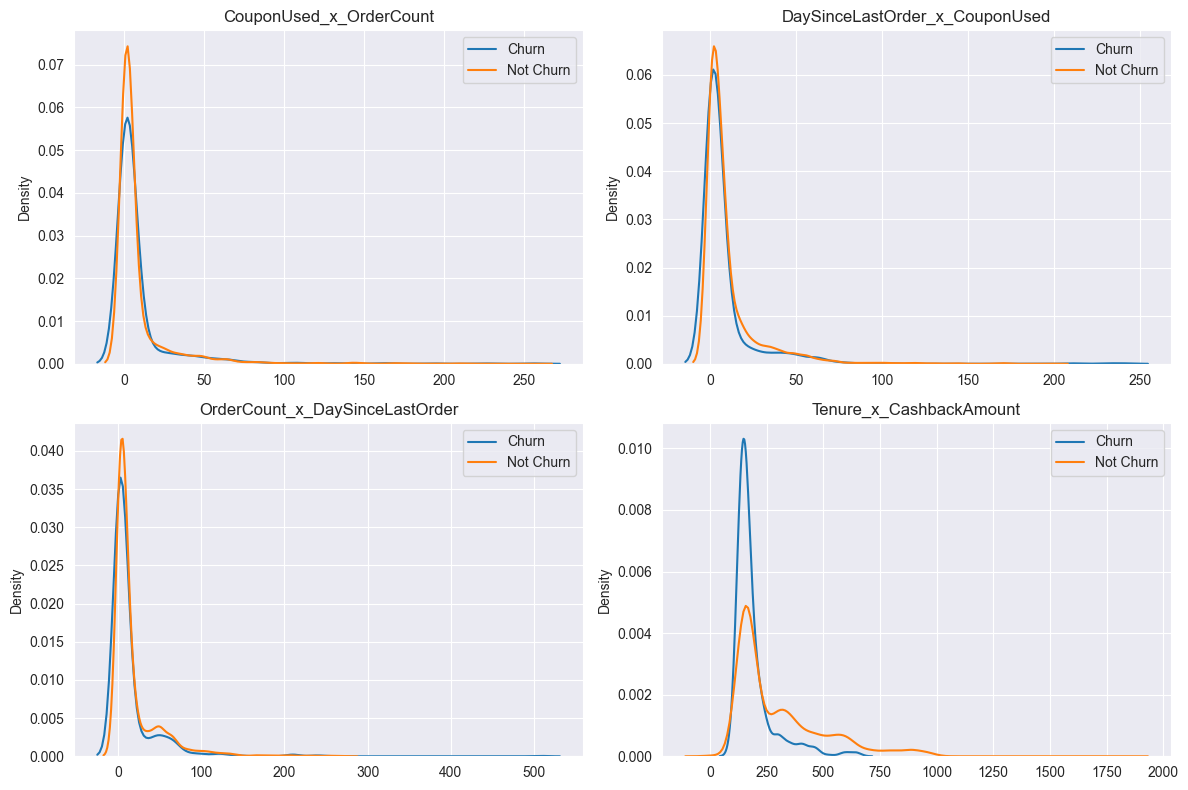

In [5]:
candidate_interactions = {
    "CouponUsed_x_OrderCount": df_raw["CouponUsed"] * df_raw["OrderCount"],
    "DaySinceLastOrder_x_CouponUsed": df_raw["DaySinceLastOrder"]
    * df_raw["CouponUsed"],
    "OrderCount_x_DaySinceLastOrder": df_raw["OrderCount"]
    * df_raw["DaySinceLastOrder"],
    "Tenure_x_CashbackAmount": df_raw["Tenure"] * df_raw["CashbackAmount"],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, series) in zip(axes.flatten(), candidate_interactions.items()):
    sns.kdeplot(series[df_raw.Churn == 1].dropna(), label="Churn", ax=ax)
    sns.kdeplot(series[df_raw.Churn == 0].dropna(), label="Not Churn", ax=ax)
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

Observation:
- CouponUsed_x_OrderCount, DaySinceLastOrder_x_CouponUsed, OrderCount_x_DaySinceLastOrder : Near-identical distributions. **Dropped.**
-  **Tenure_x_CashbackAmount** : Churners cluster tightly near zero, non-churners spread broadly. **Clear separation. Kept.**

### 4. Checking correlation for Tenure_x_CashbackAmount

In [6]:
df_temp = df_raw[["Tenure", "CashbackAmount"]].dropna()
df_temp["Tenure_Cashback"] = df_temp["Tenure"] * df_temp["CashbackAmount"]

r_tenure = pearsonr(df_temp["Tenure"], df_temp["Tenure_Cashback"]).statistic
r_cashback = pearsonr(df_temp["CashbackAmount"], df_temp["Tenure_Cashback"]).statistic
print(f"Correlation with Tenure: {r_tenure:.4f}")
print(f"Correlation with CashbackAmount: {r_cashback:.4f}")

Correlation with Tenure: 0.8871
Correlation with CashbackAmount: 0.7800


The interaction is highly correlated with Tenure. We drop raw  and  and use **only the interaction** to eliminate the correlation while preserving the richer signal.

### 5. Final features

In [16]:
df_raw["Tenure_Cashback"] = df_raw["Tenure"] * df_raw["CashbackAmount"]
df_final = df_raw.drop(["Tenure", "CashbackAmount"], axis=1)

print("Final features:", df_final.drop("Churn", axis=1).columns.tolist())
print("Shape:", df_final.shape)

Final features: ['PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'Tenure_Cashback']
Shape: (5630, 18)


This final feature set with `Tenure_Cashback` replacing `Tenure` and `Cashback`.